In [4]:
import pandas as pd
from pathlib import Path

key_nome = 'nome'
key_cognome = 'cognome'
key_patronimico = 'patronimico'

# Define the data directory path
data_dir = Path('data')

# Read CSV files with proper parsing parameters
csv_params = {
    'sep': ',',
    'skipinitialspace': True,
    'quotechar': '"',
    'on_bad_lines': 'warn'
}

df_si_mogliedi = pd.read_csv(data_dir / 'si_mogliedi.csv', **csv_params)
df_no_mogliedi = pd.read_csv(data_dir / 'no_mogliedi.csv', **csv_params)
df_donne_non_sposate = pd.read_csv(data_dir / 'lista_donne_non_sposate.csv', **csv_params)

df_no_mogliedi.columns = df_no_mogliedi.columns.str.strip().str.strip('"')
df_si_mogliedi.columns = df_si_mogliedi.columns.str.strip().str.strip('"')
df_donne_non_sposate.columns = df_donne_non_sposate.columns.str.strip().str.strip('"')

# Strip whitespace from the key columns
for col in [key_nome, key_cognome, key_patronimico]:
    df_no_mogliedi[col] = df_no_mogliedi[col].str.strip()
    df_si_mogliedi[col] = df_si_mogliedi[col].str.strip()
    df_donne_non_sposate[col] = df_donne_non_sposate[col].str.strip()

# Create set of tuples for donne_non_sposate
donne_non_sposate_set = set(df_donne_non_sposate[[key_nome, key_cognome, key_patronimico]].apply(tuple, axis=1))

# Create mask
mask_donne_non_sposate = df_no_mogliedi.apply(
    lambda row: (row[key_nome], row[key_cognome], row[key_patronimico]) in donne_non_sposate_set, axis=1
)

df_uomini = df_no_mogliedi[~mask_donne_non_sposate].copy()
df_donne_non_sposate_filtered = df_no_mogliedi[mask_donne_non_sposate].copy()

df_donne = pd.concat([df_si_mogliedi, df_donne_non_sposate_filtered], axis=0, ignore_index=True)

# Filter out men
men_to_exclude = [
    ('Eugenio', 'Casini', 'Giovacchino'),
    ('Silvano', 'Casini', 'Giovacchino'),
    ('Candido', 'Casini', 'Giovacchino'),
    ('Giuseppe', 'Francolini', 'Luigi'),
    ('Giovan_Battista', 'Casini', 'Giovacchino')
]

mask_men = df_donne.apply(
    lambda row: (row[key_nome], row[key_cognome], row[key_patronimico]) in men_to_exclude, axis=1
)

df_men_from_donne = df_donne[mask_men].copy()
df_donne = df_donne[~mask_men].copy()
df_uomini = pd.concat([df_uomini, df_men_from_donne], axis=0, ignore_index=True)

# Get unique individuals
donne = set(df_donne[[key_nome, key_cognome, key_patronimico]].apply(tuple, axis=1))
uomini = set(df_uomini[[key_nome, key_cognome, key_patronimico]].apply(tuple, axis=1))

print(f'# donne: {len(donne)}')
print(f'# uomini: {len(uomini)}')

# donne: 560
# uomini: 4365


Sample speciePro values from women data:
speciePro
casa                         622
casa_e_corte                 194
ingresso                      69
ingresso_e_casa               24
fabbricato                    20
palazzo_e_corte               14
bottega                       14
palazzo                       13
casa_(porzione)               10
casa,_corte_e_fabbricato       9
Name: count, dtype: int64

Sample keys from macro_dict:
['fortezza', 'scrittoio, stanze annesse alla Porta al Prato', 'scrittoio,_stanze_annesse_alla_Porta_al_Prato', 'scala e capanna', 'scala_e_capanna', 'palazzo con cortile, rimessa, scuderia ed annessi', 'palazzo_con_cortile,_rimessa,_scuderia_ed_annessi', 'pastura gelsata', 'pastura_gelsata', 'casa, corte e annessi', 'casa,_corte_e_annessi', 'uccelliera e fabbrica', 'uccelliera_e_fabbrica', 'oratorio e compagnia', 'oratorio_e_compagnia', 'vasca e loggia', 'vasca_e_loggia', 'casa a terreno e magazzino', 'casa_a_terreno_e_magazzino', 'prato cipressato']

Total

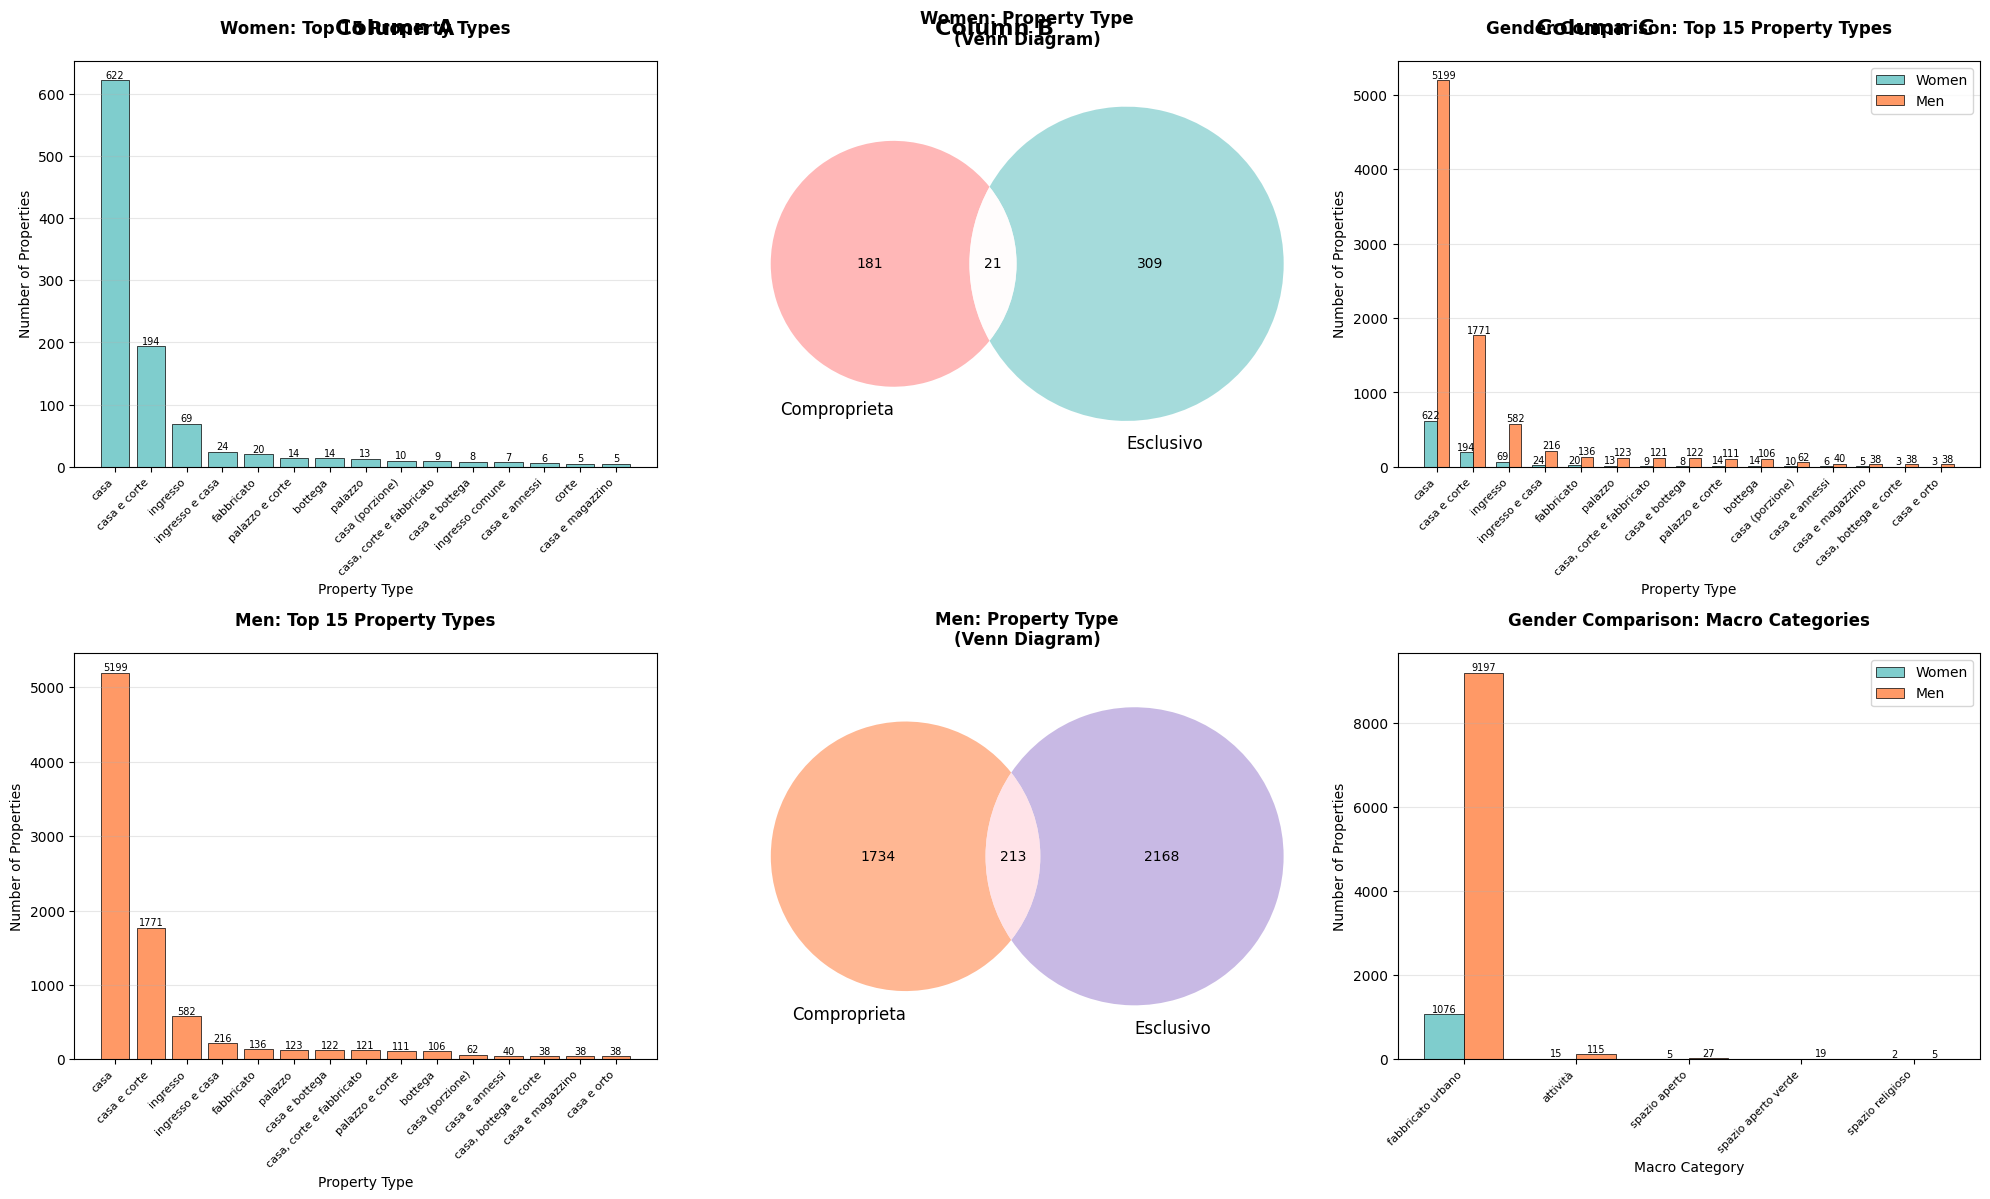


✓ Visualizations created successfully!
✓ Saved to: florentia_visualizations.png


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib_venn import venn2

# Load macro categories mapping
df_macro = pd.read_csv(data_dir / 'macro.csv')
df_macro.columns = df_macro.columns.str.strip().str.strip('"')
df_macro['specie_pro'] = df_macro['specie_pro'].str.strip()
df_macro['macro_categoria'] = df_macro['macro_categoria'].str.strip()

# Create mapping dictionary with both original and underscore-replaced versions
macro_dict = {}
for idx, row in df_macro.iterrows():
    specie = row['specie_pro']
    macro = row['macro_categoria']
    # Skip empty values
    if pd.isna(specie) or specie == '':
        continue
    # Add original
    macro_dict[specie] = macro
    # Add version with underscores replaced by spaces
    macro_dict[specie.replace(' ', '_')] = macro

# Debug: Check what's in the data
print('Sample speciePro values from women data:')
print(df_donne['speciePro'].value_counts().head(10))
print('\nSample keys from macro_dict:')
print(list(macro_dict.keys())[:20])
print(f'\nTotal keys in macro_dict: {len(macro_dict)}')

# Strip whitespace from speciePro before mapping
df_donne['speciePro'] = df_donne['speciePro'].str.strip()
df_uomini['speciePro'] = df_uomini['speciePro'].str.strip()

# Map speciePro to macro categories (direct mapping, handles both formats)
df_donne['macro_categoria'] = df_donne['speciePro'].map(macro_dict)
df_uomini['macro_categoria'] = df_uomini['speciePro'].map(macro_dict)

# Debug: print mapping success rate
print(f'\nWomen mapped: {df_donne["macro_categoria"].notna().sum()} / {len(df_donne)}')
print(f'Men mapped: {df_uomini["macro_categoria"].notna().sum()} / {len(df_uomini)}')
print('\nUnmapped women speciePro values:')
print(df_donne[df_donne['macro_categoria'].isna()]['speciePro'].value_counts().head(10))

# Create figure with 2x3 subplots
fig = plt.figure(figsize=(20, 12))

# Adjust subplot spacing to make room for column headers
fig.subplots_adjust(top=0.92, hspace=0.35)

# Add column headers with padding
fig.text(0.20, 0.96, 'Column A', ha='center', va='center', fontsize=16, fontweight='bold')
fig.text(0.50, 0.96, 'Column B', ha='center', va='center', fontsize=16, fontweight='bold')
fig.text(0.80, 0.96, 'Column C', ha='center', va='center', fontsize=16, fontweight='bold')

# Define colors
color_women = '#7FCDCD'
color_men = '#FF9966'
color_women_venn = '#FF9999'
color_men_venn = '#B19CD9'

# ============= ROW 1: WOMEN VISUALIZATIONS =============

# 1. Women: Top 15 Property Types
ax1 = plt.subplot(2, 3, 1)
tipo_per_donna = df_donne['speciePro'].value_counts().head(15)
bars = ax1.bar(range(len(tipo_per_donna)), tipo_per_donna.values, 
               color=color_women, edgecolor='black', linewidth=0.5)
ax1.set_xticks(range(len(tipo_per_donna)))
ax1.set_xticklabels([label.replace('_', ' ') for label in tipo_per_donna.index], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Number of Properties', fontsize=10)
ax1.set_xlabel('Property Type', fontsize=10)
ax1.set_title('Women: Top 15 Property Types', fontsize=12, fontweight='bold', pad=20)
ax1.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=7)

# 2. Women: Property Type (Venn Diagram)
ax2 = plt.subplot(2, 3, 2)
women_comproprieta = df_donne[df_donne['tipoPossesso'].str.contains('Comproprieta', case=False, na=False)].shape[0]
women_esclusivo = df_donne[df_donne['tipoPossesso'].str.contains('Esclusivo', case=False, na=False)].shape[0]
women_both = 21
women_comproprieta_only = 181
women_esclusivo_only = 309

venn = venn2(subsets=(women_comproprieta_only, women_esclusivo_only, women_both),
             set_labels=('Comproprieta', 'Esclusivo'),
             set_colors=(color_women_venn, color_women),
             alpha=0.7, ax=ax2)
if venn.get_label_by_id('10'):
    venn.get_label_by_id('10').set_text(str(women_comproprieta_only))
if venn.get_label_by_id('01'):
    venn.get_label_by_id('01').set_text(str(women_esclusivo_only))
if venn.get_label_by_id('11'):
    venn.get_label_by_id('11').set_text(str(women_both))
ax2.set_title('Women: Property Type\n(Venn Diagram)', fontsize=12, fontweight='bold', pad=20)

# 3. Gender Comparison: Top 15 Property Types
ax3 = plt.subplot(2, 3, 3)
all_tipos = pd.concat([df_donne['speciePro'], df_uomini['speciePro']]).value_counts().head(15).index
women_counts = [df_donne[df_donne['speciePro'] == tipo].shape[0] for tipo in all_tipos]
men_counts = [df_uomini[df_uomini['speciePro'] == tipo].shape[0] for tipo in all_tipos]

x_pos = np.arange(len(all_tipos))
width = 0.35
bars1 = ax3.bar(x_pos - width/2, women_counts, width, label='Women',
                color=color_women, edgecolor='black', linewidth=0.5)
bars2 = ax3.bar(x_pos + width/2, men_counts, width, label='Men',
                color=color_men, edgecolor='black', linewidth=0.5)

ax3.set_xticks(x_pos)
ax3.set_xticklabels([label.replace('_', ' ') for label in all_tipos], rotation=45, ha='right', fontsize=8)
ax3.set_ylabel('Number of Properties', fontsize=10)
ax3.set_xlabel('Property Type', fontsize=10)
ax3.set_title('Gender Comparison: Top 15 Property Types', fontsize=12, fontweight='bold', pad=20)
ax3.legend(loc='upper right')
ax3.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=7)

# ============= ROW 2: MEN VISUALIZATIONS =============

# 4. Men: Top 15 Property Types
ax4 = plt.subplot(2, 3, 4)
tipo_per_uomo = df_uomini['speciePro'].value_counts().head(15)
bars = ax4.bar(range(len(tipo_per_uomo)), tipo_per_uomo.values,
               color=color_men, edgecolor='black', linewidth=0.5)
ax4.set_xticks(range(len(tipo_per_uomo)))
ax4.set_xticklabels([label.replace('_', ' ') for label in tipo_per_uomo.index], rotation=45, ha='right', fontsize=8)
ax4.set_ylabel('Number of Properties', fontsize=10)
ax4.set_xlabel('Property Type', fontsize=10)
ax4.set_title('Men: Top 15 Property Types', fontsize=12, fontweight='bold', pad=20)
ax4.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=7)

# 5. Men: Property Type (Venn Diagram)
ax5 = plt.subplot(2, 3, 5)
men_comproprieta = df_uomini[df_uomini['tipoPossesso'].str.contains('Comproprieta', case=False, na=False)].shape[0]
men_esclusivo = df_uomini[df_uomini['tipoPossesso'].str.contains('Esclusivo', case=False, na=False)].shape[0]
men_both = 213
men_comproprieta_only = 1734
men_esclusivo_only = 2168

venn = venn2(subsets=(men_comproprieta_only, men_esclusivo_only, men_both),
             set_labels=('Comproprieta', 'Esclusivo'),
             set_colors=(color_men, color_men_venn),
             alpha=0.7, ax=ax5)
if venn.get_label_by_id('10'):
    venn.get_label_by_id('10').set_text(str(men_comproprieta_only))
if venn.get_label_by_id('01'):
    venn.get_label_by_id('01').set_text(str(men_esclusivo_only))
if venn.get_label_by_id('11'):
    venn.get_label_by_id('11').set_text(str(men_both))
ax5.set_title('Men: Property Type\n(Venn Diagram)', fontsize=12, fontweight='bold', pad=20)

# 6. Gender Comparison: Macro Categories
ax6 = plt.subplot(2, 3, 6)
# Filter out NaN values and get top macro categories
all_macros = pd.concat([df_donne['macro_categoria'], df_uomini['macro_categoria']]).dropna().value_counts().head(10).index

if len(all_macros) > 0:
    women_macro_counts = [df_donne[df_donne['macro_categoria'] == macro].shape[0] for macro in all_macros]
    men_macro_counts = [df_uomini[df_uomini['macro_categoria'] == macro].shape[0] for macro in all_macros]
    
    x_pos2 = np.arange(len(all_macros))
    width = 0.35
    bars1 = ax6.bar(x_pos2 - width/2, women_macro_counts, width, label='Women',
                    color=color_women, edgecolor='black', linewidth=0.5)
    bars2 = ax6.bar(x_pos2 + width/2, men_macro_counts, width, label='Men',
                    color=color_men, edgecolor='black', linewidth=0.5)
    
    ax6.set_xticks(x_pos2)
    ax6.set_xticklabels(all_macros, rotation=45, ha='right', fontsize=8)
    ax6.set_ylabel('Number of Properties', fontsize=10)
    ax6.set_xlabel('Macro Category', fontsize=10)
    ax6.set_title('Gender Comparison: Macro Categories', fontsize=12, fontweight='bold', pad=20)
    ax6.legend(loc='upper right')
    ax6.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax6.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(height)}', ha='center', va='bottom', fontsize=7)
else:
    ax6.text(0.5, 0.5, 'No macro category data available\nCheck mapping', 
            ha='center', va='center', transform=ax6.transAxes, fontsize=12)
    ax6.set_title('Gender Comparison: Macro Categories', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig('florentia_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n✓ Visualizations created successfully!')
print(f'✓ Saved to: florentia_visualizations.png')

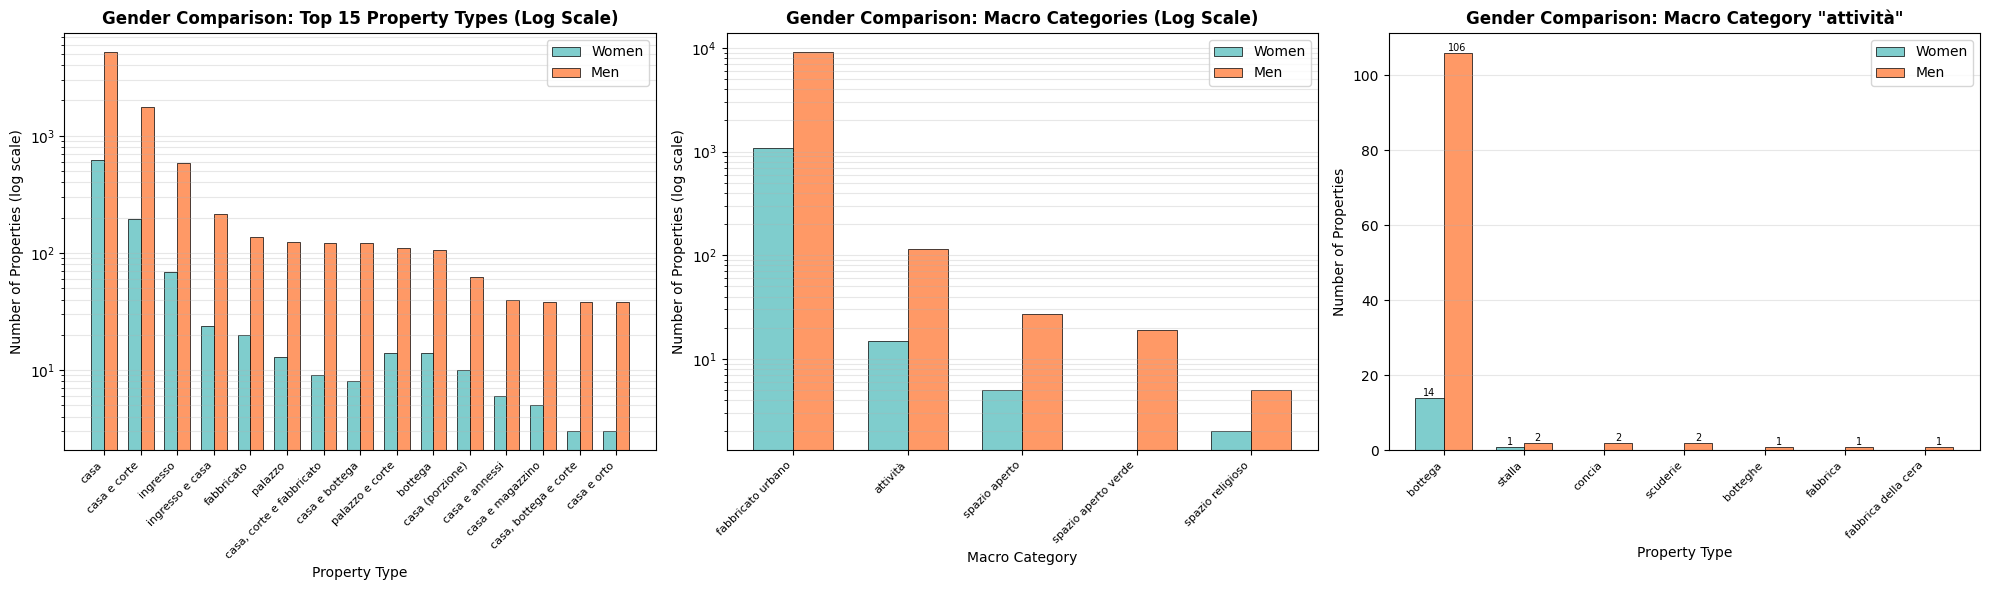


✓ Log scale visualizations created successfully!
✓ Saved to: florentia_visualizations_log_scale.png

Statistics for "attività" macro category:
  Women: 15 properties
  Men: 115 properties


In [6]:
# Create visualization for attività macro category
fig2 = plt.figure(figsize=(12, 6))

# Define colors (same as before)
color_women = '#7FCDCD'
color_men = '#FF9966'

# Gender Comparison: Macro Category "attività" only
ax3 = plt.subplot(1, 1, 1)

# Filter for only "attività" macro category
df_donne_attivita = df_donne[df_donne['macro_categoria'] == 'attività']
df_uomini_attivita = df_uomini[df_uomini['macro_categoria'] == 'attività']

# Get all property types within "attività" category
attivita_tipos = pd.concat([df_donne_attivita['speciePro'], df_uomini_attivita['speciePro']]).value_counts().head(15).index

if len(attivita_tipos) > 0:
    women_attivita_counts = [df_donne_attivita[df_donne_attivita['speciePro'] == tipo].shape[0] for tipo in attivita_tipos]
    men_attivita_counts = [df_uomini_attivita[df_uomini_attivita['speciePro'] == tipo].shape[0] for tipo in attivita_tipos]
    
    x_pos3 = np.arange(len(attivita_tipos))
    width = 0.35
    bars1 = ax3.bar(x_pos3 - width/2, women_attivita_counts, width, label='Women',
                    color=color_women, edgecolor='black', linewidth=0.5)
    bars2 = ax3.bar(x_pos3 + width/2, men_attivita_counts, width, label='Men',
                    color=color_men, edgecolor='black', linewidth=0.5)
    
    ax3.set_xticks(x_pos3)
    ax3.set_xticklabels([label.replace('_', ' ') for label in attivita_tipos], rotation=45, ha='right', fontsize=8)
    ax3.set_ylabel('Number of Properties', fontsize=10)
    ax3.set_xlabel('Property Type', fontsize=10)
    ax3.set_title('Gender Comparison: Macro Category "attività"', fontsize=12, fontweight='bold')
    ax3.legend(loc='upper right')
    ax3.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:  # Only show label if there's a value
                ax3.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(height)}', ha='center', va='bottom', fontsize=7)
else:
    ax3.text(0.5, 0.5, 'No data for "attività" macro category', 
            ha='center', va='center', transform=ax3.transAxes, fontsize=12)
    ax3.set_title('Gender Comparison: Macro Category "attività"', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('florentia_visualizations_attivita.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n✓ Attività visualization created successfully!')
print(f'✓ Saved to: florentia_visualizations_attivita.png')
print(f'\nStatistics for "attività" macro category:')
print(f'  Women: {len(df_donne_attivita)} properties')
print(f'  Men: {len(df_uomini_attivita)} properties')